# [QLoRA - Quantized LoRA](https://www.runpod.io/articles/guides/how-to-fine-tune-large-language-models-on-a-budget?utm_source=chatgpt.com)
QLoRA(Quantized Low-Rank Adaptation)는 **대규모 언어 모델을 극도로 적은 GPU 메모리로 파인튜닝**하기 위해 제안된 기법이다.

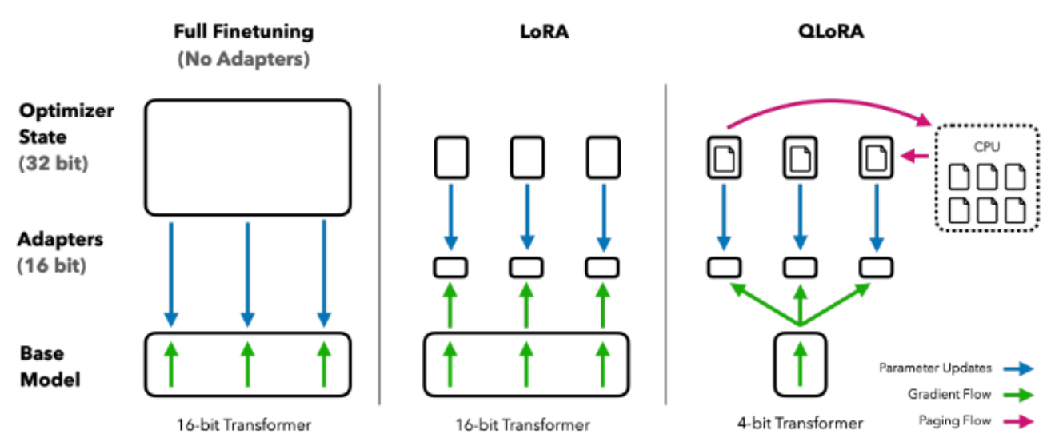

## QLoRA 핵심 구성 요소

### 1. NF4 (NormalFloat 4-bit)

**NF4**는 QLoRA에서 사용하는 **4비트 양자화 데이터 타입**이다.

- LLM 가중치가 **정규분포(N(0,1))에 가깝다는 통계적 특성**을 기반으로 설계됨
- 기존 `INT4`나 `FP4` 대비 **양자화 오차를 최소화**
- bitsandbytes 라이브러리에서 제공

#### 핵심 특징
- 4bit로 가중치를 표현하면서도 FP16에 가까운 성능 유지
- weight distribution에 최적화된 비균등(non-uniform) 양자화
- QLoRA 성능 유지의 가장 중요한 요소

> 즉, **NF4는 “LLM 가중치에 특화된 4bit 표현 방식”**이다.

### 2. DQ (Double Quantization, 이중 양자화)

**Double Quantization(DQ)**은  
4비트로 양자화된 가중치를 보정하기 위해 사용하는 **scale 값 자체를 다시 양자화**하는 기법이다.

#### 일반적인 양자화
- Weight → 4bit
- Scale / Zero-point → FP16 또는 FP32

#### Double Quantization
- Weight → 4bit (NF4)
- Scale → 다시 8bit로 양자화
```css
FP16 Weight
↓
4bit NF4 Weight + FP16 Scale
↓
8bit Quantized Scale
```

#### 효과
- scale 저장에 필요한 메모리 추가 절감
- 파라미터당 약 **0.37 bit** 추가 절약
- 수십억 파라미터 모델에서 **수백 MB VRAM 감소**

> DQ는 필수는 아니지만, **QLoRA의 메모리 효율을 극대화하는 핵심 최적화**이다.

### 3. LoRA (Low-Rank Adaptation)

**LoRA**는 QLoRA에서 실제로 **학습이 이루어지는 부분**이다.

- 기존 모델의 가중치는 **동결(frozen)**
- Attention / MLP 층에 **저차원(rank-r) 어댑터만 추가**
- 학습 파라미터 수를 극단적으로 감소

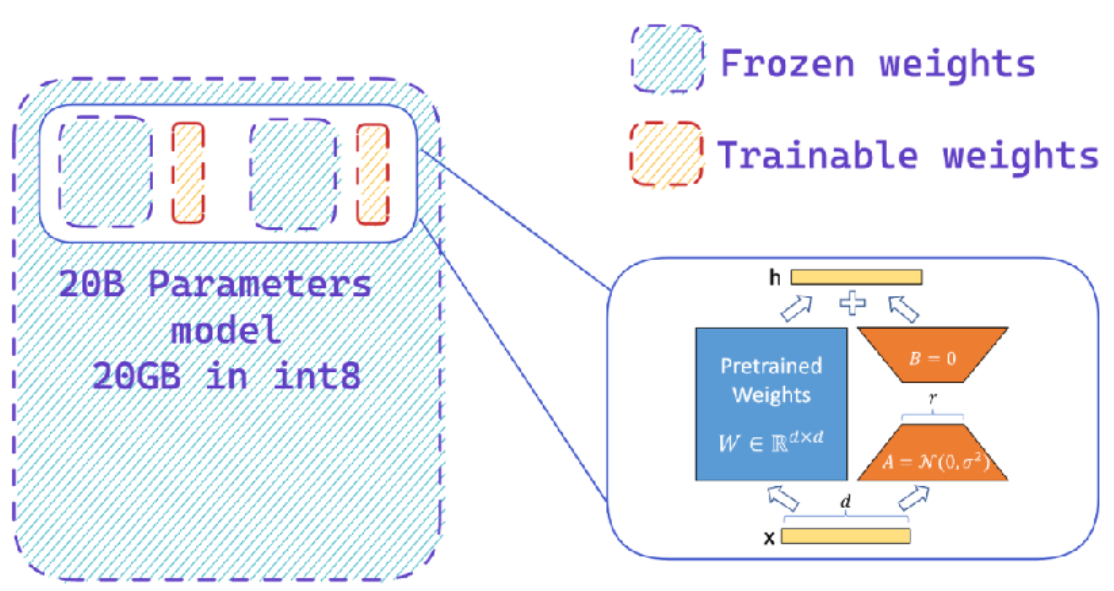

#### QLoRA에서의 역할
- 4bit로 양자화된 base model은 **업데이트하지 않음**
- LoRA 파라미터만 FP16/BF16으로 학습
- Backward 시에도 base weight는 4bit 상태 유지

> 즉, **QLoRA에서 학습 가능한 유일한 파라미터는 LoRA 어댑터**이다.

## QLoRA 전체 구조 요약
> **QLoRA는 사전학습 모델을 4비트 NF4와 이중 양자화로 메모리 효율적으로 고정한 뒤, LoRA 어댑터만 학습하여 Full Fine-tuning에 근접한 성능을 달성하는 저자원 파인튜닝 기법이다.**

```css
[Base Model]

4bit NF4 Quantized

Double Quantization 적용

Frozen (학습 안 함)

[Trainable Parameters]

LoRA Adapters (FP16 / BF16)
```

# [Unsloth](https://unsloth.ai/)

Unsloth는 대규모 언어 모델(LLM)의 파인튜닝(Fine-tuning) 속도를 극적으로 높이고 메모리 사용량을 줄여주는 오픈소스 프레임워크입니다.

## Unsloth 장점 

- `압도적인 속도`: Hugging Face의 기본 학습 방식보다 보통 2배에서 5배까지 더 빠릅니다. (이미지에서 보신 것처럼 "2x faster"라는 문구가 뜨는 이유입니다.)

- `메모리 효율성 (0% 메모리 단편화)`: GPU 메모리를 매우 알뜰하게 사용합니다. 덕분에 메모리가 부족해서 발생하는 Out of Memory (OOM) 에러를 획기적으로 줄여주며, 더 큰 배치 사이즈나 긴 문장(max_seq_length)을 학습시킬 수 있습니다.

- `정확도 유지`: 속도는 빠르지만 모델의 품질(정확도)은 떨어뜨리지 않습니다. 수학적으로 최적화된 커널(Triton)을 사용하여 계산 효율만 높였기 때문입니다.

- `쉬운 사용법`: 기존 Hugging Face의 SFTTrainer나 TRL 라이브러리와 완벽하게 호환되도록 설계되어, 기존 코드를 아주 조금만 수정해도 바로 사용할 수 있습니다.

## Unsloth LoRA / QLoRA 장점

| 관점           | 장점                  | 설명                                  |
| ------------ | ------------------- | ----------------------------------- |
| 🚀 속도        | **학습 속도 매우 빠름**     | 커스텀 CUDA 커널 + 최적화된 forward/backward |
| 💾 메모리       | **VRAM 사용량 최소**     | 4bit 로딩 + QLoRA 기본 설계               |
| 🧠 난이도       | **설정이 단순함**         | YAML 없음, Python 몇 줄로 끝              |
| 🧪 실험        | **빠른 반복 실험 가능**     | 하이퍼파라미터 변경 부담 낮음                    |
| 💻 하드웨어      | **단일 GPU로 충분**      | 24GB GPU에서도 7B~13B 가능               |
| 🎓 강의        | **입문자 친화적**         | 멀티 GPU / 분산 개념 없이 설명 가능             |
| 🧩 통합        | **Transformers 호환** | HF Trainer / PEFT 생태계 그대로 사용        |
| 🔄 저장        | **HF Hub 업로드 간단**   | `push_to_hub()` 바로 가능               |
| 🛠 디버깅       | **에러 지점 명확**        | 분산/ZeRO 개념 없음                       |
| 🧑‍💻 개발 생산성 | **코드 가독성 높음**       | “무슨 일이 일어나는지” 바로 보임                 |

## [Unsloth Models](https://docs.unsloth.ai/get-started/all-our-models)

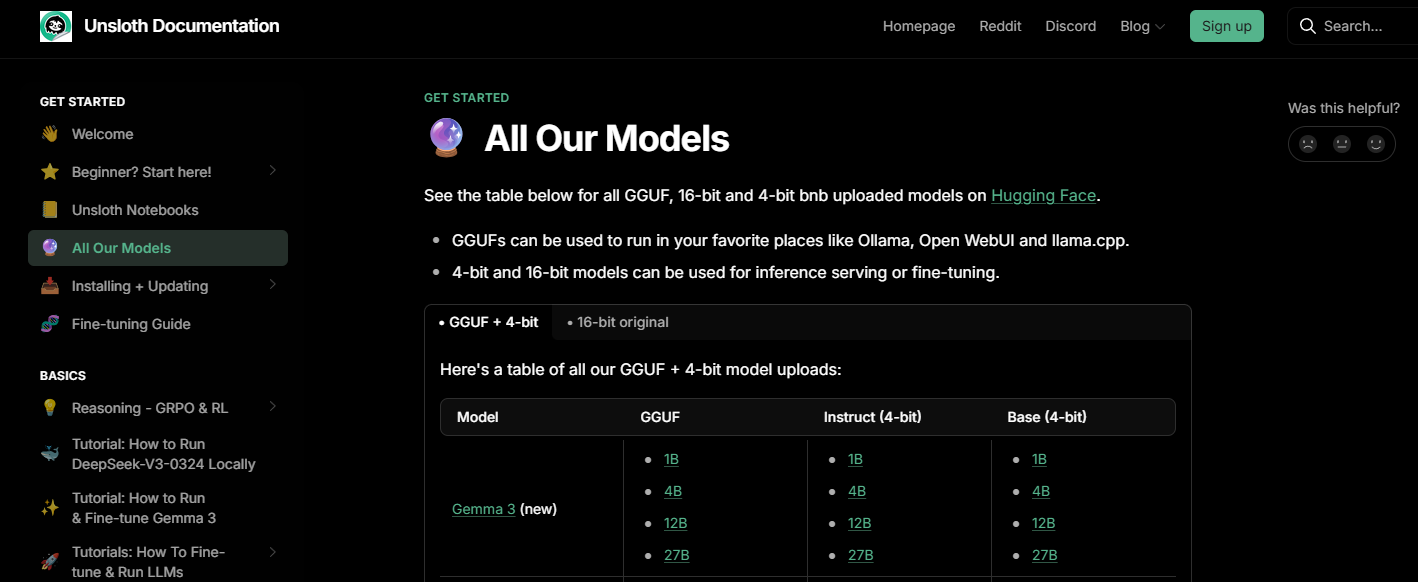

# [예제](https://docs.unsloth.ai/get-started/unsloth-notebooks)

### API 등록
- [WandB API](https://wandb.ai/authorize)
- [HuggingFace API Key](https://huggingface.co/settings/tokens)

In [1]:
from dotenv import load_dotenv

# .env 파일에 기록된 환경 변수를 시스템으로 불러옵니다.
load_dotenv() 


True

In [2]:
import sys
from tqdm import tqdm as std_tqdm

# 주피터 위젯 버전의 tqdm을 일반 텍스트 버전으로 덮어씌웁니다.
import tqdm.notebook as tqdm_notebook
tqdm_notebook.tqdm = std_tqdm

## [Load Model](https://huggingface.co/unsloth)

In [3]:
from unsloth import FastModel
import torch

fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",

    # Other popular models!
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/Llama-3.3-70B",
    "unsloth/mistral-7b-instruct-v0.3",
    "unsloth/Phi-4",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-1b-it",
    max_seq_length = 8184, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.5: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.044 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gemma3 does not support SDPA - switching to fast eager.


### 학습전 - Inference

In [ ]:
from datasets import load_dataset

# dataset = load_dataset("csv", data_files="./data/nutrition.csv", split="train")
dataset = load_dataset("good593/nutrition-dataset", split="train")

df = dataset.to_pandas()
df.shape 

(198, 6)

In [5]:
input_test = "소아청소년과 전문의로서 아이가 잘 안 먹는 이유는 뭐라고 생각해요?"

print(df[df['user_input'] == input_test]['reference'].values[0])

아이를 잘 먹지 못해 병원을 찾는 부모가 많습니다. 잘 안 먹는다고 내원하는 아이들 중에는 병이나 다른 이상이 없어 특별한 치료가 필요 없는 경우가 생각보다 많습니다. 가장 먼저 확인해야 할 것은 아이의 몸무게입니다. 몸무게가 많이 나가는 아이는 이미 체중이 충분히 늘어난 경우가 많아 잘 안 먹는 것이 정상입니다. 부모가 억지로 더 먹이려 하면 아이가 스스로 체중을 조절할 기회를 잃게 되고, 오히려 비만으로 이어질 수 있습니다. 또한, 체중에 문제가 없는 경우에도 아이는 일시적으로 잘 안 먹을 수 있으며, 특별한 병이 없다면 대부분 저절로 좋아집니다.


In [6]:
messages = [{
    "role": "user",
    "content": input_test,
}]

text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize=False,               # 반드시 False로 해야 문자열 반환됨
)

In [7]:
from transformers import TextStreamer

_ = model.generate(
    **tokenizer([text], return_tensors = "pt").to("cuda"),
    max_new_tokens = 100, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

소아청소년과 전문의로서 아이가 잘 안 먹는 경우, 다양한 원인이 있을 수 있습니다. 몇 가지 가능성과 그 이유, 그리고 확인해야 할 사항들을 자세히 설명해 드릴게요.

**1. 흔한 원인들**

*   **영양 불량증 (Duodenum):**
    *   **잘못된 영양소 섭취:** 탄수화물, 단백질, 지방, 비타민, 미네랄


## PEFT : QLoRA

In [8]:
qlora_model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # Turn off for just text!
    finetune_language_layers   = True,  # Should leave on!
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,  # SHould leave on always!
    r = 16,           # 0보다 큰 어떤 숫자도 선택 가능! 8, 16, 32, 64, 128이 권장됩니다.
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",   # 바이어스를 지원합니다.
    random_state = 3407
)

Unsloth: Making `model.base_model.model.model` require gradients


## datasets

### QLoRA용 학습 데이터셋 크기 비교 

| 강의 목적 | 데이터 수         | 추천    |
| ----- | ------------- | ----- |
| 개념·데모 | 100 ~ 300     | ⭐⭐⭐⭐⭐ |
| 실습 위주 | 500 ~ 1,000   | ⭐⭐⭐⭐  |
| 성능 체감 | 2,000 ~ 5,000 | ⭐⭐⭐   |

In [10]:
# EOS_TOKEN은 문장의 끝을 나타내는 토큰입니다. 이 토큰을 추가해야 합니다.
EOS_TOKEN = tokenizer.eos_token

# AlpacaPrompt를 사용하여 지시사항을 포맷팅하는 함수입니다.
alpaca_prompt = """Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{}

### Response:
{}"""

# 주어진 예시들을 포맷팅하는 함수입니다.
def formatting_prompts_func(examples):
    instructions = examples["user_input"]  # 지시사항을 가져옵니다.
    outputs = examples["reference"]  # 출력값을 가져옵니다.
    texts = []  # 포맷팅된 텍스트를 저장할 리스트입니다.
    for instruction, output in zip(instructions, outputs):
        # EOS_TOKEN을 추가해야 합니다. 그렇지 않으면 생성이 무한히 진행될 수 있습니다.
        text = alpaca_prompt.format(instruction, output) + EOS_TOKEN
        texts.append(text)
    return {
        "text": texts,  # 포맷팅된 텍스트를 반환합니다.
    }

# 데이터셋에 formatting_prompts_func 함수를 적용합니다. 배치 처리를 활성화합니다.
dataset = dataset.map(
    formatting_prompts_func,
    batched=True,
)

In [11]:
dataset[0]

{'user_input': '체중에 대한 잘못된 정보는 무엇인가요?',
 'reference': "'하루 1,000ml만 넘지 않으면 괜찮다'는 이야기는 잘못된 정보입니다. 실제로 하루 1,000ml 정도 먹는 아기는 드물고, 이런 아기들 중에는 체중 과다나 이유식 문제 등 다른 문제가 있는 경우가 많습니다.",
 'reference_video_url': 'https://www.youtube.com/watch?v=08B0VqzITbU',
 'persona_name': 'a pediatric nutrition expert',
 'query_style': 'MISSPELLED',
 'query_length': 'SHORT',
 'text': "Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\n체중에 대한 잘못된 정보는 무엇인가요?\n\n### Response:\n'하루 1,000ml만 넘지 않으면 괜찮다'는 이야기는 잘못된 정보입니다. 실제로 하루 1,000ml 정도 먹는 아기는 드물고, 이런 아기들 중에는 체중 과다나 이유식 문제 등 다른 문제가 있는 경우가 많습니다.<end_of_turn>"}

### Split Train & Test

In [12]:
dataset = dataset.train_test_split(test_size=0.1) # 10%를 검증용으로
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

## Train

### SFTTrainer를 사용하여 모델 학습 설정

| 비교 항목 | steps 전략 | epoch 전략 |
| :--- | :--- | :--- |
| **데이터 크기** | 대용량 (Big Data) | 소량~중간 (Small/Medium) |
| **평가 빈도** | 설정한 스텝마다 (자주) | 에폭이 끝날 때마다 (가끔) |
| **피드백 속도** | 빠름 (중간에 멈추기 좋음) | 느림 (끝날 때까지 기다림) |
| **추천 상황** | LLM 큐로라(QLoRA) 학습 시 | 일반적인 분류/회귀 모델 학습 |

In [13]:
from trl import SFTConfig

sft_args = SFTConfig(
    max_seq_length=4096,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    num_train_epochs=50,          # 데이터가 적으므로 충분한 기회를 주되
    max_steps=-1,                 # num_train_epochs를 끝까지 활용하기 위해 -1로 설정
    
    # --- 전략 수정 (데이터가 적을 때는 epoch 단위가 더 정확함) ---
    eval_strategy="epoch",        # 매 에폭이 끝날 때마다 평가
    save_strategy="epoch",        # 매 에폭이 끝날 때마다 저장
    # --------------------------------------------------------
    
    load_best_model_at_end=True,  # 가장 낮은 loss를 기록한 모델을 최종 선택
    metric_for_best_model="loss",
    greater_is_better=False,      # loss는 낮을수록 좋음
    save_total_limit=2,           # 용량 관리를 위해 가장 좋은 체크포인트 2개만 유지
    
    logging_steps=1,
    learning_rate=1e-4,           # 데이터가 적을 땐 학습률을 살짝 낮추는 것이 안정적 (2e-4 -> 1e-4 권장)
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="paged_adamw_8bit",     # 메모리 효율을 위해 paged 버전 권장
    weight_decay=0.05,            # 데이터가 적을 땐 규제(Weight Decay)를 조금 더 강하게 (0.01 -> 0.05)
    lr_scheduler_type="cosine",
    seed=123,
    output_dir="outputs",
    report_to="wandb",
    run_name="small-data-finetuning",
)

In [14]:
from trl import SFTTrainer
from transformers import EarlyStoppingCallback

tokenizer.padding_side = "right"  # 토크나이저의 패딩을 오른쪽으로 설정합니다.

# SFTTrainer를 사용하여 모델 학습 설정
trainer = SFTTrainer(
    model=qlora_model,  # 학습할 모델
    tokenizer=tokenizer,  # 토크나이저
    train_dataset=train_dataset,  # 학습 데이터셋
    eval_dataset=eval_dataset,# 테디노트에서 추가된 eval dataset
    dataset_text_field="text",  # 데이터셋에서 텍스트 필드의 이름
    dataset_num_proc=2,  # 데이터 처리에 사용할 프로세스 수
    packing=False,  # 짧은 시퀀스에 대한 학습 속도를 5배 빠르게 할 수 있음
    args=sft_args,  # SFT 학습 파라미터
    # 성능 개선이 5번의 평가 동안 없으면 학습 조기 종료
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] 
)

num_proc must be <= 20. Reducing num_proc to 20 for dataset of size 20.
[datasets.arrow_dataset|WARNING]num_proc must be <= 20. Reducing num_proc to 20 for dataset of size 20.


### Show current memory stats

In [15]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA L4. Max memory = 22.044 GB.
1.016 GB of memory reserved.


### Training model

In [16]:
# @title Training model
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 178 | Num Epochs = 50 | Total steps = 1,150
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,045,760 of 1,012,931,712 (1.29% trained)
wandb: Currently logged in as: goodwon593 (goodwon593-student-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Epoch,Training Loss,Validation Loss
1,2.041100,1.927287
2,1.390200,1.640527
3,1.384800,1.536469
4,1.174500,1.498226
5,0.656900,1.543660
6,0.448000,1.610233
7,0.499500,1.753911
8,0.196300,1.874715
9,0.295300,2.010190


Unsloth: Not an error, but Gemma3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,▇▃▂▁▂▃▄▆█
eval/runtime,█▁▁▁▁▁▁▁▁
eval/samples_per_second,▁████████
eval/steps_per_second,▁████████
train/epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,▄▂▂▂▂▂▂▁▁▁▁▁▁▂▁▂▂▂▂▂▂▂▃▃▄▃▃▅▃▃▄▃▃▃▂▄▄▃▄█
train/learning_rate,▁▄█████████████████████████████████████▇
train/loss,█▇▇▄▅▅▅▄▄▄▃▄▃▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
eval/loss,2.01019
eval/runtime,0.7746


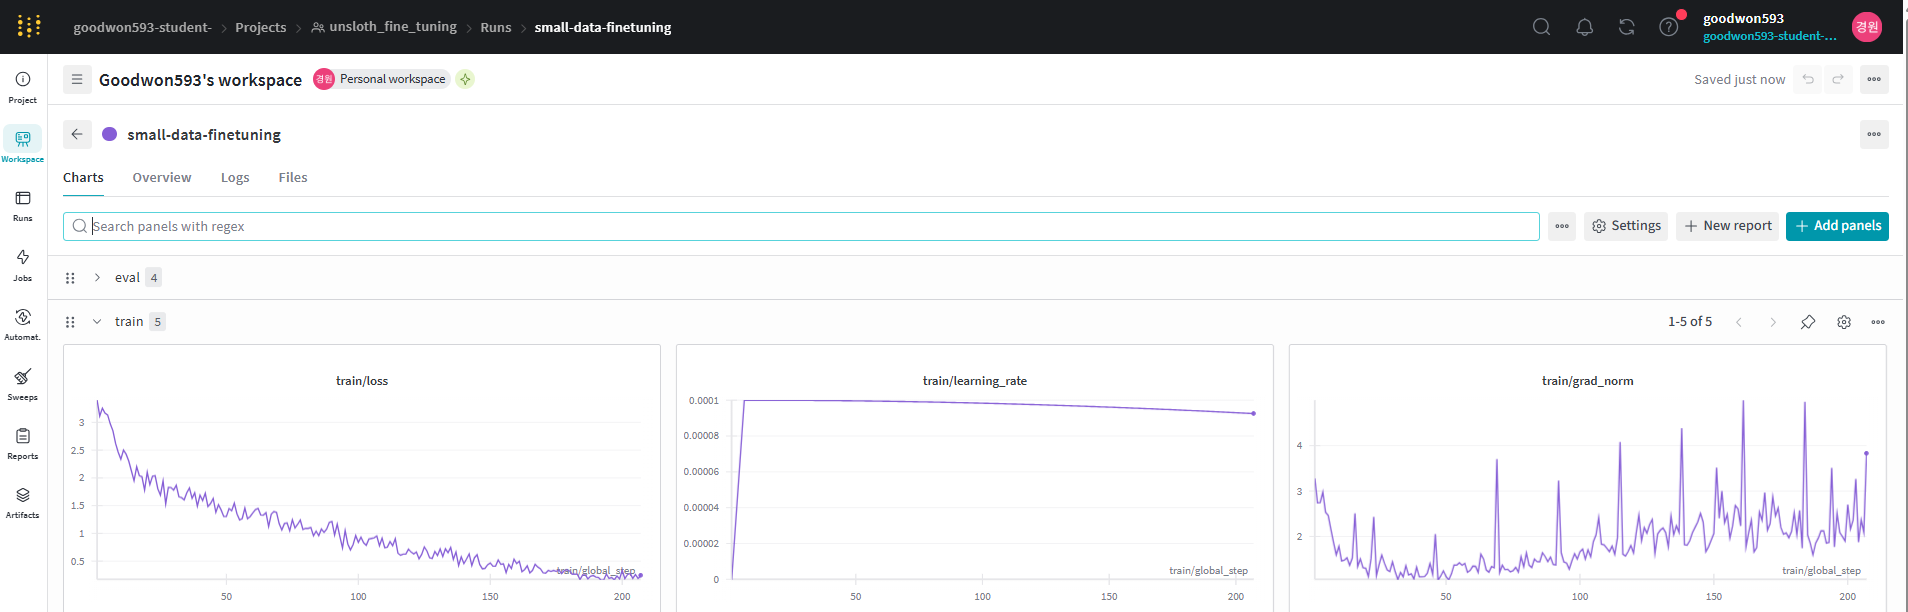

### Show final memory and time stats

In [17]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

339.2663 seconds used for training.
5.65 minutes used for training.
Peak reserved memory = 2.664 GB.
Peak reserved memory for training = 1.648 GB.
Peak reserved memory % of max memory = 12.085 %.
Peak reserved memory for training % of max memory = 7.476 %.


## 학습 후 - Inference

### Tokenizer

In [18]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma-3",
)

### messages

In [19]:
input_test

'소아청소년과 전문의로서 아이가 잘 안 먹는 이유는 뭐라고 생각해요?'

In [20]:
messages = [{
    "role": "user",
    "content": input_test,
}]

text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True, # Must add for generation
    tokenize=False,               # 반드시 False로 해야 문자열 반환됨
)

### generate answer

In [21]:
from transformers import TextStreamer

_ = qlora_model.generate(
    **tokenizer([text], return_tensors = "pt").to("cuda"),
    max_new_tokens = 200, # Increase for longer outputs!
    # Recommended Gemma-3 settings!
    temperature = 1.0, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

소아청소년과 전문의로서 아이가 잘 안 먹는 이유는 다양하게 발생할 수 있습니다. 가장 흔한 원인을 꼽자면 다음과 같습니다.

**1. 영양 부족:**

*   **영양소 부족:** 일반적인 식사 패턴을 유지하지 않으면 채소, 과일, 잡곡류 등 영양소가 균형 있게 포함된 음식은 부족해 당장 잘 안 먹을 수 있습니다. 특히 비타민, 미네랄 등 필수 영양소 부족은 식욕 부진의 주요 원인이 됩니다.

*   **알레르기 또는 비만증:** 특정 음식에 대한 이유식 시작 후 알레르기 증상이나 비만증이 발생하면 아이가 특정 음식에 익숙해지기 어렵고 식욕이 떨어질 수 있습니다.

**2. 심리적 요인:**

*   **정서적 이유식:** 부모가 음식을 조작하거나 질투


## save model

In [22]:
save_model_nm = "unsloth-gemma3-1b-finetune-nutrition"

qlora_model.save_pretrained_merged(
    save_model_nm,
    tokenizer
)

Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:05<00:00,  5.94s/it]


Unsloth: Merge process complete. Saved to `/workspace/lectures/unsloth-gemma3-1b-finetune-nutrition`


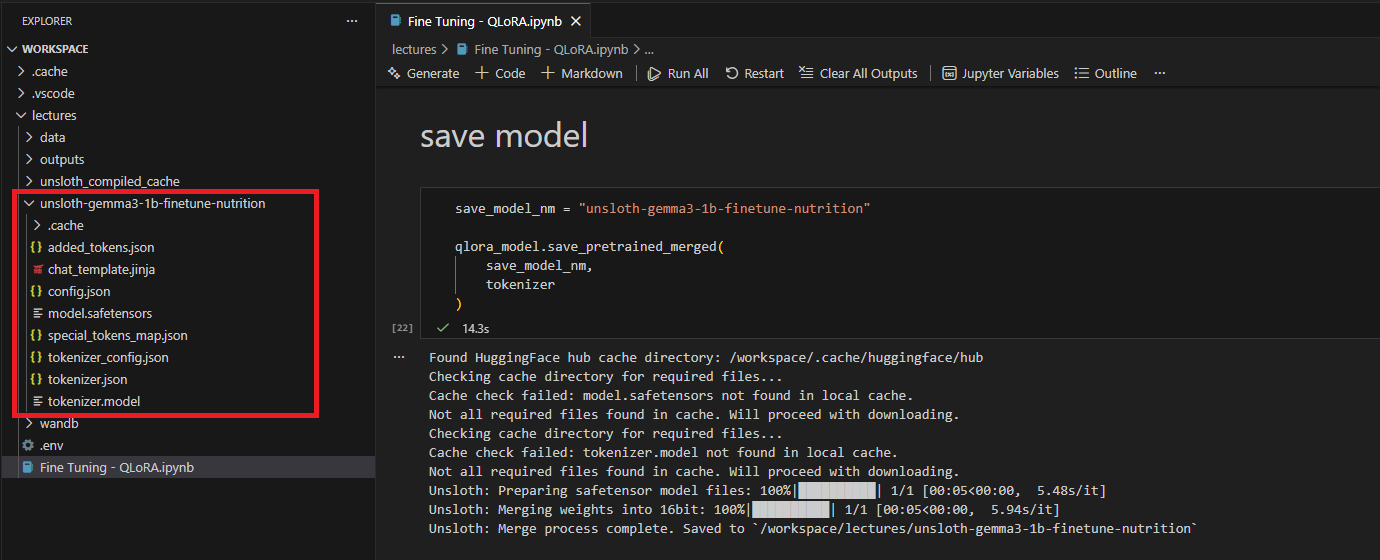

## HuggingFace 업로드

In [23]:
import os
from huggingface_hub import login

login(
    token=os.environ["HF_TOKEN"]
)
print("로그인 성공")

로그인 성공


### 기존 레포지토리 삭제 

In [24]:
from huggingface_hub import delete_repo

# 사용자의 Hugging Face 계정 ID
huggingface_id = "good593"
new_repo_id = f"{huggingface_id}/{save_model_nm}"
print(f"new_repo_id: {new_repo_id}")

try:
    
    # 지정된 저장소를 완전히 삭제
    delete_repo(repo_id=new_repo_id)
    print("삭제가 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("삭제할 대상이 없습니다.")

new_repo_id: good593/unsloth-gemma3-1b-finetune-nutrition
삭제할 대상이 없습니다.


### 수동 업로드

In [25]:
from huggingface_hub import create_repo

try:
    
    # 지정된 저장소를 생성
    create_repo(
        repo_id=new_repo_id, 
        repo_type="model",   # 모델 저장소
        private=False)
    print("생성이 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("생성할 대상이 없습니다.")

생성이 완료되었습니다.


In [26]:
from huggingface_hub import upload_folder

# 로컬 폴더 전체를 Hub 저장소에 업로드
print(f"save_model_nm: {save_model_nm}")
print(f"new_repo_id: {new_repo_id}")

upload_folder(
    folder_path=f"./{save_model_nm}",                    # 업로드할 로컬 폴더 경로
    path_in_repo=".",                                # 저장소 루트에 그대로 업로드
    repo_id=new_repo_id,   # 대상 저장소 (username/repo-name)
    commit_message="Upload finetuned model"
)

save_model_nm: unsloth-gemma3-1b-finetune-nutrition
new_repo_id: good593/unsloth-gemma3-1b-finetune-nutrition


Processing Files (3 / 3): 100%|██████████| 2.04GB / 2.04GB,  131MB/s  
New Data Upload: 100%|██████████| 1.40GB / 1.40GB,  131MB/s  


CommitInfo(commit_url='https://huggingface.co/good593/unsloth-gemma3-1b-finetune-nutrition/commit/85902d8dc7358dcfec64dce6f17c074fd97a4cdc', commit_message='Upload finetuned model', commit_description='', oid='85902d8dc7358dcfec64dce6f17c074fd97a4cdc', pr_url=None, repo_url=RepoUrl('https://huggingface.co/good593/unsloth-gemma3-1b-finetune-nutrition', endpoint='https://huggingface.co', repo_type='model', repo_id='good593/unsloth-gemma3-1b-finetune-nutrition'), pr_revision=None, pr_num=None)

### [hugging face 확인](https://huggingface.co/good593/unsloth-gemma3-1b-finetune-nutrition)

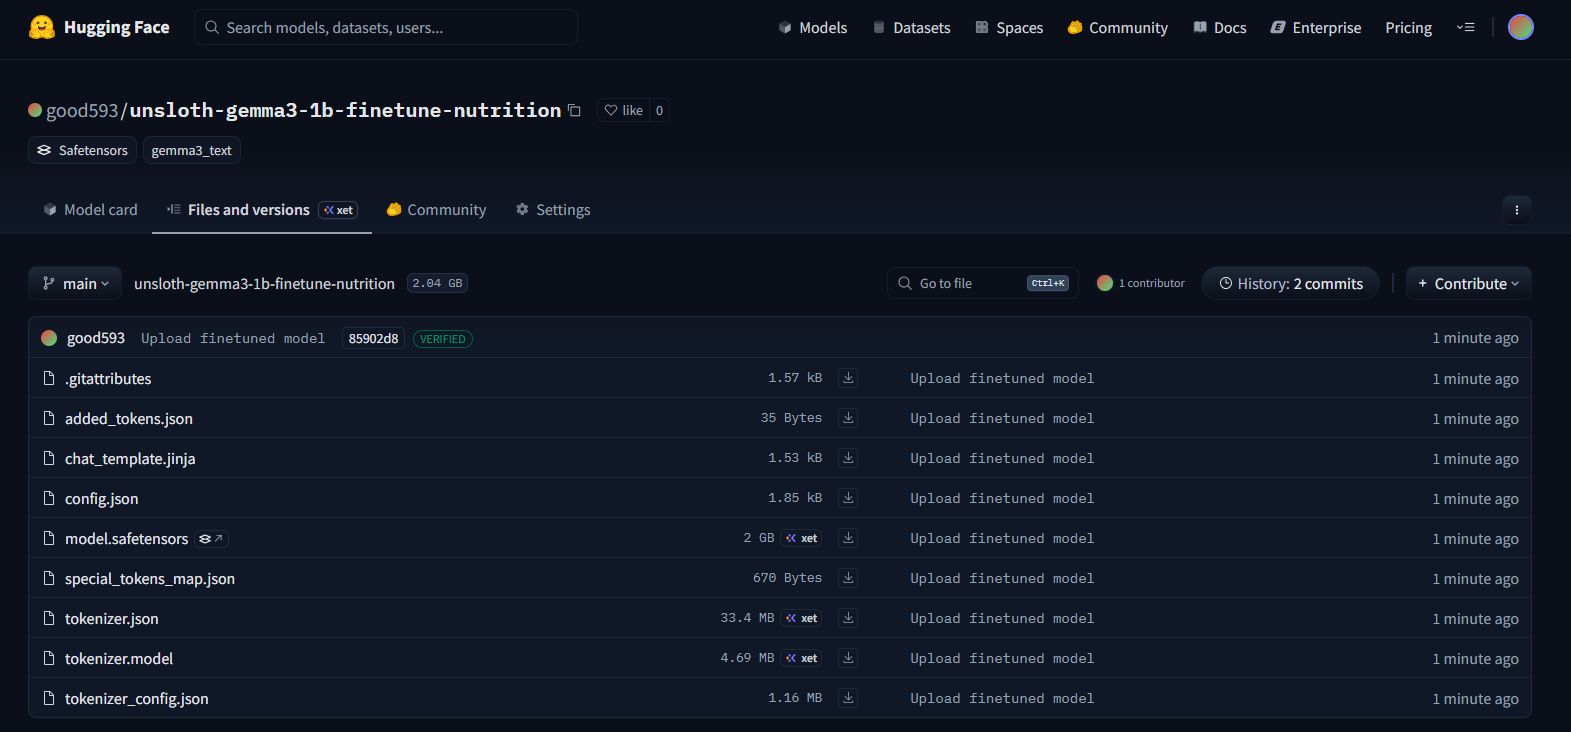